# Archiv: Code that I won't use

In [ ]:
#Archiv Datensätze mit 30peaks

#(X) ATAC_seq_IL17f via function

def ATAC_seq_Gene(ATAC_data_removed, gene):

    atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains(fr'\b{gene}\b', case=False, na=False)].copy()

    atac_gene_num = atac_gene.drop(annotation_cols, axis=1)

    X = atac_gene_num.T                 
    X_labels = atac_gene['ImmGenATAC1219.peakID'].values

    return atac_gene, X, X_labels


ATAC_Il17f, X, X_labels = ATAC_seq_Gene(ATAC_data_removed, "Il17f")
ATAC_seq_IL17f

#(Y) RNA_seq_IL17f via function

def Y_Gene(RNA_seq, gene):

    RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == gene].drop("Unnamed: 0", axis=1, errors="ignore").copy()
    
    Y = RNA_seq_Gene.T

    return RNA_seq_Gene, Y


RNA_seq_IL17f, Y = Y_Gene(RNA_seq, "Il17f")
RNA_seq_IL17f

NameError: name 'ATAC_data_removed' is not defined

In [ ]:
RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == "Il17f"].drop("Unnamed: 0", axis=1, errors="ignore").copy()

#Only those peaks that are within 100kB of the GOI
atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains("Il17f", case=False, na=False)].copy()
atac_gene_num = atac_gene.drop(annotation_cols, axis=1)


#Check Correlation of each peak with Gene Expression
correlation_Il17f = []

for peak in atac_gene_num.columns:
    corr = atac_gene_num.loc[peak].corr(RNA_seq_Gene.iloc[0])
    correlation_Il17f.append([peak, corr])

correlation_Il17f

#Choose only Top 5 peaks



KeyError: 'LTHSC.34-.BM'

In [ ]:
#via LinearRegression
linreg = LinearRegression()
linreg.fit(X, Y)

r2 = linreg.score(X_scaled, Y)
print("r^2:", round(r2, 3))

#Cross Validation
scores = cross_val_score(linreg, X_scaled, np.ravel(Y), cv=5, scoring="r2")
print("CV R^2 pro Fold:", scores.round(3))
print("CV scores mean:", round(scores.mean(), 3))


r^2: -0.045
CV R^2 pro Fold: [-2.213730e+02 -5.267890e+02 -8.886000e+00  1.740000e-01 -3.291423e+03]
CV scores mean: -809.659


In [ ]:
#via Ridge
ridgereg = Ridge(alpha=1.0)
ridgereg.fit(X_scaled, Y)

r2 = ridgereg.score(X_scaled, Y)
print("r^2:", r2)

#Cross Validation
scores = cross_val_score(ridgereg, X_scaled, np.ravel(Y), cv=5, scoring="r2")
print("CV R^2 pro Fold:", scores.round(3))
print("CV scores mean:", round(scores.mean(), 3))

r^2: 0.8972795473173509
CV R^2 pro Fold: [-2.16174e+02 -4.78971e+02 -1.50120e+01  1.02000e-01 -2.70894e+03]
CV scores mean: -683.799


In [ ]:
##(Y) RNA_seq_IL17f via function


def Y_Gene(RNA_seq, gene):

    RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == gene].drop("Unnamed: 0", axis=1, errors="ignore").copy()
    
    Y = RNA_seq_Gene.iloc[0]

    return RNA_seq_Gene, Y


RNA_Seq_Gene, Y = Y_Gene(RNA_seq, "Il17f")
RNA_seq_IL17f

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
7817,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.13509,1.017884,1.040295,1.017884,1.021351


In [ ]:
##(X) ATAC_seq_IL17f via function

def ATAC_seq_Gene(ATAC_data_removed, gene, Y):

    atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains(fr'\b{gene}\b', case=False, na=False)].copy()

    atac_gene_num = atac_gene.drop(annotation_cols, axis=1)

    X = atac_gene_num.T                 
    X_labels = atac_gene['ImmGenATAC1219.peakID'].values

    common_cells = X.index.intersection(Y.index)
    X = X.loc[common_cells]
    Y = Y.loc[common_cells]

    Y = Y.loc[X.index]

    correlation = []

    for i in X.index:
        corr = X.loc[i].corr(Y)
        correlation.append([i, corr])

    return atac_gene, X, X_labels, correlation


ATAC_Il17f, X, X_labels, correlation = ATAC_seq_Gene(ATAC_data_removed, "Il17f", Y)
correlation

[['LTHSC.34-.BM', nan],
 ['LTHSC.34+.BM', nan],
 ['STHSC.150-.BM', nan],
 ['MPP4.135+.BM', nan],
 ['proB.CLP.BM', nan],
 ['proB.FrA.BM', nan],
 ['proB.FrBC.BM', nan],
 ['B.FrE.BM', nan],
 ['B1b.PC', nan],
 ['B.T1.Sp', nan],
 ['B.T2.Sp', nan],
 ['B.T3.Sp', nan],
 ['B.Sp', nan],
 ['B.Fem.Sp', nan],
 ['B.MZ.Sp', nan],
 ['B.Fo.Sp', nan],
 ['B.mem.Sp', nan],
 ['B.GC.CB.Sp', nan],
 ['B.GC.CC.Sp', nan],
 ['B.PB.Sp', nan],
 ['B.PC.Sp', nan],
 ['B.PC.BM', nan],
 ['preT.DN1.Th', nan],
 ['preT.DN2a.Th', nan],
 ['preT.DN2b.Th', nan],
 ['preT.DN3.Th', nan],
 ['T.DN4.Th', nan],
 ['T.ISP.Th', nan],
 ['T.DP.Th', nan],
 ['T.4.Th', nan],
 ['T.8.Th', nan],
 ['T.4.Nve.Sp', nan],
 ['T.4.Nve.Fem.Sp', nan],
 ['T.8.Nve.Sp', nan],
 ['T.4.Sp.aCD3+CD40.18hr', nan],
 ['Treg.4.FP3+.Nrplo.Co', nan],
 ['Treg.4.25hi.Sp', nan],
 ['T8.TN.P14.Sp', nan],
 ['T8.TE.LCMV.d7.Sp', nan],
 ['T8.MP.LCMV.d7.Sp', nan],
 ['T8.Tcm.LCMV.d180.Sp', nan],
 ['T8.Tem.LCMV.d180.Sp', nan],
 ['NKT.Sp', nan],
 ['NKT.Sp.LPS.3hr', nan],
 ['NKT.

In [ ]:
#Index anpassen
 
common_cells = X.index.intersection(Y.index)
X = X.loc[common_cells]
Y = Y.loc[common_cells]

Y = Y.loc[X.index]

X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-trasnformation

**Ergebnis:** Cross-Validation zeigt uns, dass das Modell nicht funktionieren wird. Problem: Overfitting

### 2.4.Poster:

#### 1) Creating dictionaries

## ChatGPT Plots:

### 2.4.6: Repressive Promotors?

### 2.4.7: Location of repressive CREs relative to activating CREs

In [ ]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'

Gene_annotations = pd.read_csv(gene_annotations_path, sep="\t", names=cols)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def plot_cre_location(gen_name, bin_width=10_000, min_abs_coef=None):
    """
    Gewichtetes Histogramm der Regressions-CREs relativ zum TSS.

    Blau = repressiv (Ridge-Koeffizient < 0)
    Rot  = aktivierend (Ridge-Koeffizient > 0)

    Die Balkenhöhe ist die Summe der absoluten Ridge-Koeffizienten
    innerhalb jedes 10-kb-Bins, nicht nur die Anzahl der Peaks.
    """

    # 1. Alle Peaks und Ridge-Koeffizienten aus dem Regressionsmodell
    coef_df, r2, cv, _ = coef_gen(gen_name)

    coef_df = coef_df.copy()
    coef_df["peakID"] = coef_df["peakID"].astype(str)
    coef_df = coef_df.drop_duplicates(subset="peakID")

    # 2. TSS strangkorrekt bestimmen
    Gene_annotations["TSS_pos"] = Gene_annotations.apply(
        lambda row: row["txStart"] if row["strand"] == "+" else row["txEnd"],
        axis=1
    )

    # TSS-Position des untersuchten Gens auswählen
    tss_df = (
        Gene_annotations.loc[
            Gene_annotations["gene_name"].eq(gen_name),
            ["gene_name", "TSS_pos"]
        ]
        .drop_duplicates(subset="gene_name")
        .copy()
    )

    if tss_df.empty:
        raise ValueError(f"Kein TSS für {gen_name} in Gene_annotations gefunden.")

    # 3. Summit-Positionen aller ATAC-Peaks holen
    peak_position_df = (
        ATACseq_gd_reg[
            ["ImmGenATAC1219.peakID", "Summit"]
        ]
        .copy()
        .rename(columns={"ImmGenATAC1219.peakID": "peakID"})
    )

    peak_position_df["peakID"] = peak_position_df["peakID"].astype(str)

    # 4. Peaks aus dem Regressionsmodell mit Position und TSS verbinden
    plot_df = (
        coef_df
        .merge(peak_position_df, on="peakID", how="inner")
        .merge(tss_df, how="cross")
    )

    # 5. Genomische Distanz vom Peak-Summit zum TSS
    plot_df["distance"] = plot_df["Summit"] - plot_df["TSS_pos"]

    # Nur Peaks innerhalb des verwendeten ±100-kb-Fensters
    plot_df = plot_df[plot_df["distance"].abs() <= 100_000].copy()

    # Optional: sehr schwache Koeffizienten ausschließen
    if min_abs_coef is not None:
        plot_df = plot_df[
            plot_df["coefficient"].abs() >= min_abs_coef
        ].copy()

    # Koeffizienten von exakt 0 ausschließen
    plot_df = plot_df[plot_df["coefficient"] != 0].copy()

    if plot_df.empty:
        raise ValueError(f"Für {gen_name} wurden keine Peaks zum Plotten gefunden.")

    # 6. Positiv = aktivierend, negativ = repressiv
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    # Effektstärke: ungerundeter absoluter Ridge-Koeffizient
    plot_df["abs_coef_raw"] = plot_df["coefficient"].abs()

    # 7. 10-kb-Bins über ±100 kb
    bins = np.arange(-100_000, 100_000 + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Gewichtete Summe der Koeffizienten je Bin
    activating_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "activating", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "repressive", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    # 8. Plot
    fig, ax = plt.subplots(figsize=(11, 5.5))

    bar_width = bin_width * 0.42

    ax.bar(
        bin_centers - bar_width / 2,
        repressive_strength,
        width=bar_width,
        color="#1f77b4",
        edgecolor="black",
        linewidth=0.3,
        label="Repressive CREs (β < 0)"
    )

    ax.bar(
        bin_centers + bar_width / 2,
        activating_strength,
        width=bar_width,
        color="#d62728",
        edgecolor="black",
        linewidth=0.3,
        label="Activating CREs (β > 0)"
    )

    # TSS bei Distanz 0 markieren
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="TSS"
    )

    ax.set_title(
        f"Location and effect strength of repressive vs activating CREs: {gen_name}"
    )
    ax.set_xlabel("Distance to TSS (kb)")
    ax.set_ylabel("Sum of absolute Ridge coefficients")
    ax.set_xlim(-100_000, 100_000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1000:.0f}")
    )

    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Gene: {gen_name}")
    print(f"R²: {r2:.3f}")
    print(f"CV: {cv}")
    print("\nNumber of peaks:")
    print(
        plot_df["effect"]
        .value_counts()
        .reindex(["repressive", "activating"], fill_value=0)
    )

    return plot_df, fig, ax

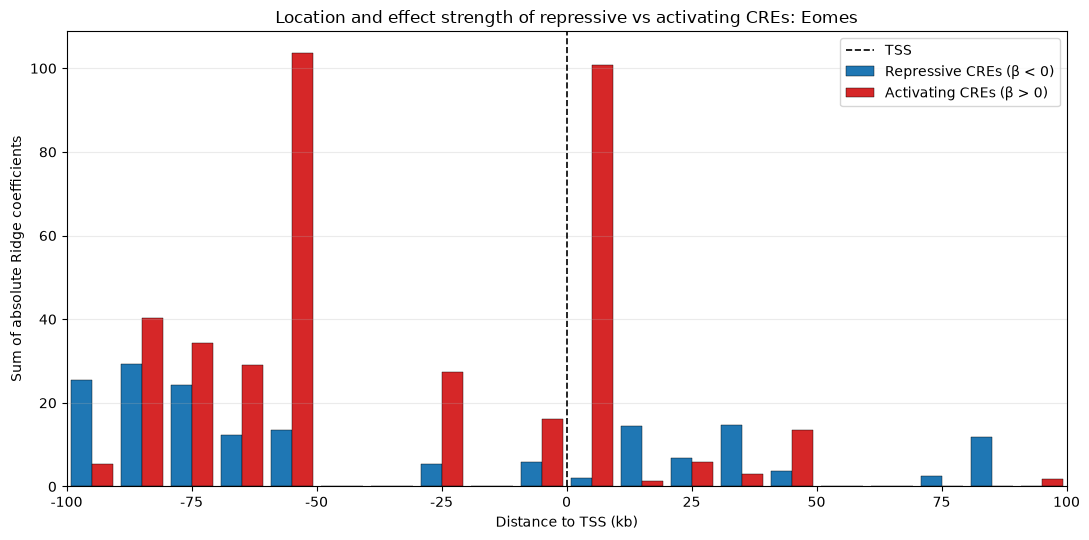

Gene: Eomes
R²: 0.986
CV: 0.9277633173458287

Number of peaks:
effect
repressive    27
activating    33
Name: count, dtype: int64


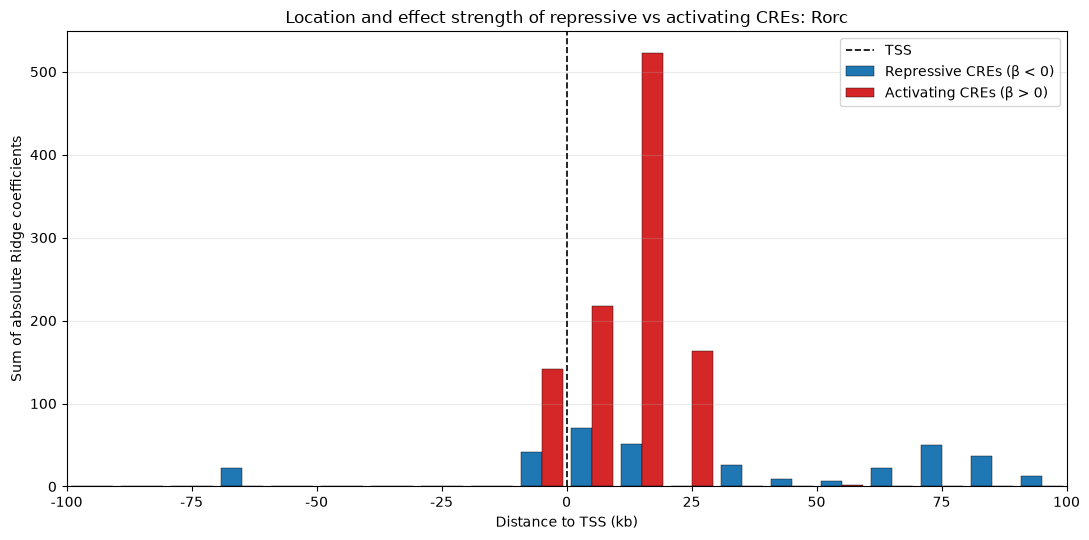

Gene: Rorc
R²: 0.905
CV: 0.6588147802771551

Number of peaks:
effect
repressive    25
activating    21
Name: count, dtype: int64


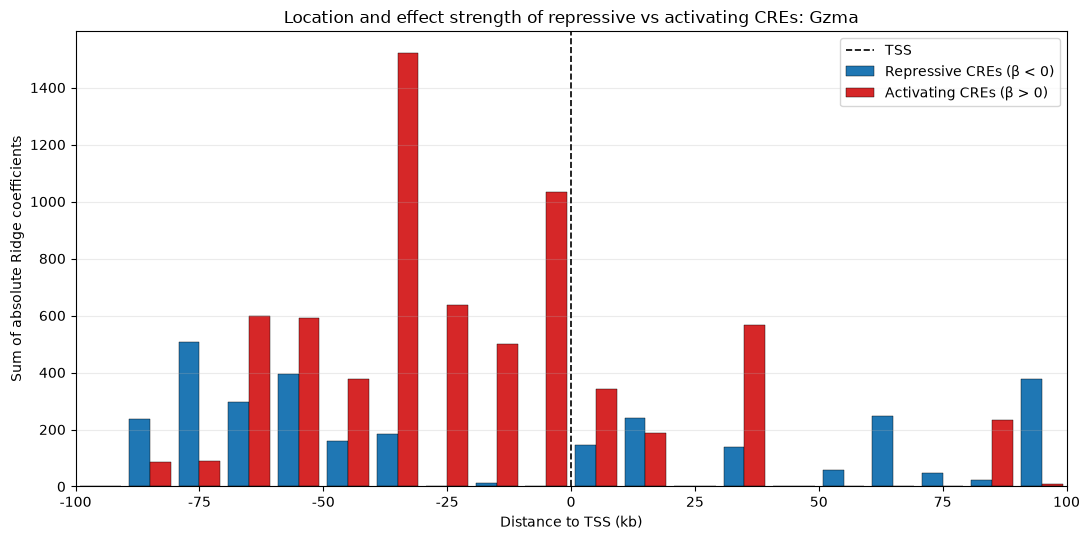

Gene: Gzma
R²: 0.986
CV: 0.8988520809298424

Number of peaks:
effect
repressive    29
activating    33
Name: count, dtype: int64


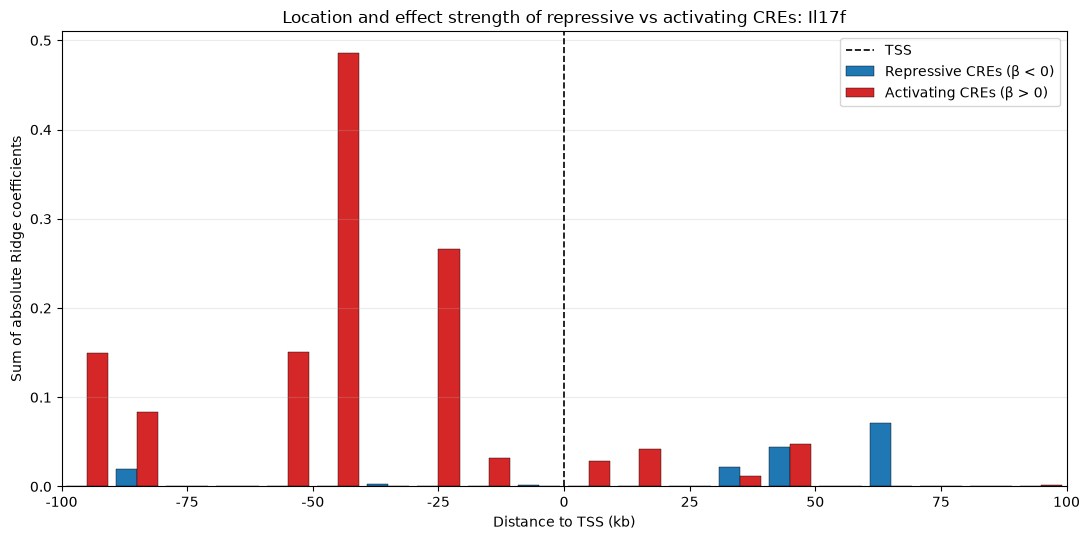

Gene: Il17f
R²: 0.054
CV: -4.164615646432379

Number of peaks:
effect
repressive    11
activating    17
Name: count, dtype: int64


In [ ]:
eomes_location_df, fig, ax = plot_cre_location("Eomes")
rorc_location_df, fig, ax = plot_cre_location("Rorc")
gzma_location_df, fig, ax = plot_cre_location("Gzma")
Il17f_location_df, fig, ax = plot_cre_location("Il17f")

#display(eomes_location_df.sort_values("distance")[["peakID", "distance", "coefficient", "effect"]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def highlight_peak_in_location_plot(
    location_df,
    peak_id,
    gen_name="Il17f",
    bin_width=10_000
):
    """
    Zeichnet den CRE-Location-Plot und hebt einen bestimmten Peak hervor.

    Parameters
    ----------
    location_df : DataFrame
        Zum Beispiel Il17f_location_df aus plot_cre_location().
        Muss mindestens peakID, distance und coefficient enthalten.

    peak_id : str
        Die Peak-ID, die hervorgehoben werden soll.

    gen_name : str
        Name für den Plot-Titel.

    bin_width : int
        Breite der genomischen Bins in bp, Standard = 10 kb.
    """

    plt.rcParams.update({
        "font.family": "Tahoma",
        "font.size": 10
    })

    # Kopie erstellen, damit das ursprüngliche DataFrame nicht verändert wird
    plot_df = location_df.copy()
    plot_df["peakID"] = plot_df["peakID"].astype(str)

    # Prüfen, ob die benötigten Spalten existieren
    required_columns = {"peakID", "distance", "coefficient"}

    if not required_columns.issubset(plot_df.columns):
        raise ValueError(
            "location_df benötigt mindestens die Spalten: "
            "'peakID', 'distance' und 'coefficient'."
        )

    # Nur Peaks im ±100-kb-Fenster und mit echtem Effekt behalten
    plot_df = plot_df[
        (plot_df["distance"].abs() <= 100_000)
        & (plot_df["coefficient"] != 0)
    ].copy()

    # Aktivierend oder repressiv aus dem Ridge-Koeffizienten bestimmen
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    # Ungerundete Effektstärke für die gewichteten Balken
    plot_df["abs_coef_raw"] = plot_df["coefficient"].abs()

    # Eingegebene Peak-ID suchen
    highlighted_peak = plot_df[
        plot_df["peakID"].eq(str(peak_id))
    ].copy()

    if highlighted_peak.empty:
        raise ValueError(
            f"Peak-ID '{peak_id}' wurde nicht in {gen_name}_location_df gefunden."
        )

    # Falls es ausnahmsweise mehrere Zeilen mit derselben Peak-ID gibt
    highlighted_peak = highlighted_peak.iloc[0]

    # Bins und Bin-Mittelpunkte definieren
    bins = np.arange(-100_000, 100_000 + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Gewichtete Summen der absoluten Koeffizienten pro Bin
    activating_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "activating", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "repressive", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    # Passenden Bin des hervorgehobenen Peaks bestimmen
    peak_distance = highlighted_peak["distance"]

    peak_bin_index = np.searchsorted(
        bins,
        peak_distance,
        side="right"
    ) - 1

    # Sonderfall: Peak liegt exakt auf der letzten Grenze bei +100 kb
    peak_bin_index = min(
        max(peak_bin_index, 0),
        len(bin_centers) - 1
    )

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(11, 5.5))

    bar_width = bin_width * 0.42

    ax.bar(
        bin_centers - bar_width / 2,
        repressive_strength,
        width=bar_width,
        color="#4C78A8",
        edgecolor="black",
        linewidth=0.3,
        label="Repressive CREs (β < 0)"
    )

    ax.bar(
        bin_centers + bar_width / 2,
        activating_strength,
        width=bar_width,
        color="#C94C4C",
        edgecolor="black",
        linewidth=0.3,
        label="Activating CREs (β > 0)"
    )

    # TSS markieren
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="TSS"
    )

    # Prüfen, ob der Peak in einem aktivierenden oder repressiven Balken liegt
    if highlighted_peak["effect"] == "activating":
        peak_bar_height = activating_strength[peak_bin_index]
    else:
        peak_bar_height = repressive_strength[peak_bin_index]

    # Exakte Peak-Position markieren
    ax.axvline(
        peak_distance,
        color="#F4C542",
        linestyle=":",
        linewidth=2,
        zorder=4
    )

    # Stern oberhalb des zugehörigen Balkens
    ax.scatter(
        peak_distance,
        peak_bar_height,
        s=220,
        marker="*",
        color="#F4C542",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
        label="Highlighted peak"
    )

    # Annotation mit Peak-ID, Distanz und Koeffizient
    ax.annotate(
        (
            f"{highlighted_peak['peakID']}\n"
            f"distance = {peak_distance / 1000:.1f} kb\n"
            f"β = {highlighted_peak['coefficient']:.3f}"
        ),
        xy=(peak_distance, peak_bar_height),
        xytext=(0, 28),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        arrowprops={
            "arrowstyle": "-",
            "color": "black",
            "linewidth": 0.8
        }
    )

    ax.set_title(
        f"Location and effect strength of CREs: {gen_name}"
    )
    ax.set_xlabel("Distance to TSS (kb)")
    ax.set_ylabel("Sum of absolute Ridge coefficients")
    ax.set_xlim(-100_000, 100_000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1000:.0f}")
    )

    max_height = max(
        activating_strength.max(),
        repressive_strength.max()
    )

    ax.set_ylim(0, max_height * 1.25)

    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(
        highlighted_peak[
            ["peakID", "distance", "coefficient", "effect", "abs_coef_raw"]
        ].to_frame().T
    )

    return highlighted_peak, fig, ax

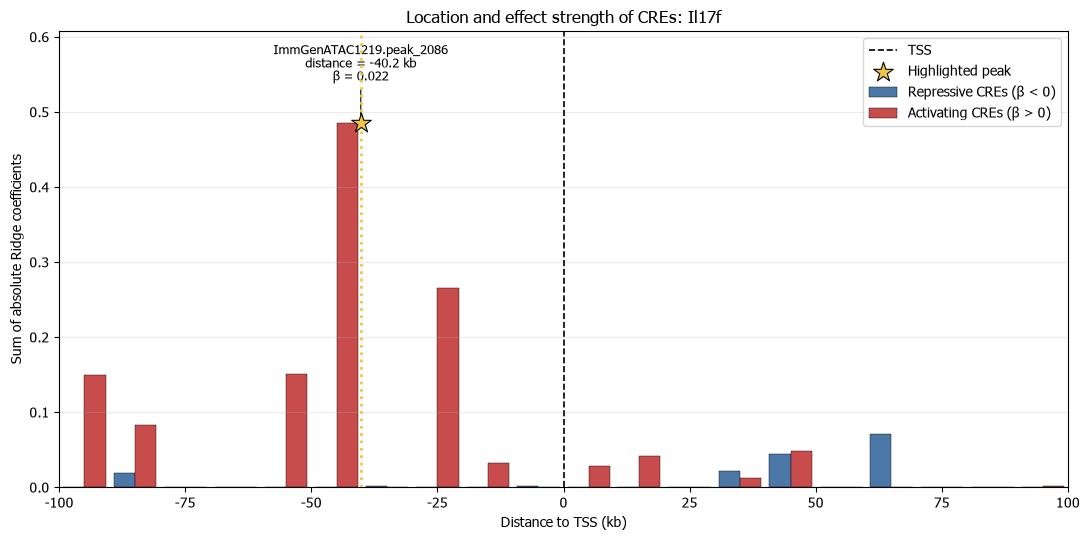

,peakID,distance,coefficient,effect,abs_coef_raw
10,ImmGenATAC1219.peak_2086,-40200,0.021907,activating,0.021907


In [ ]:
special_peak, fig, ax = highlight_peak_in_location_plot(
    Il17f_location_df,
    peak_id="ImmGenATAC1219.peak_2086",
    gen_name="Il17f")

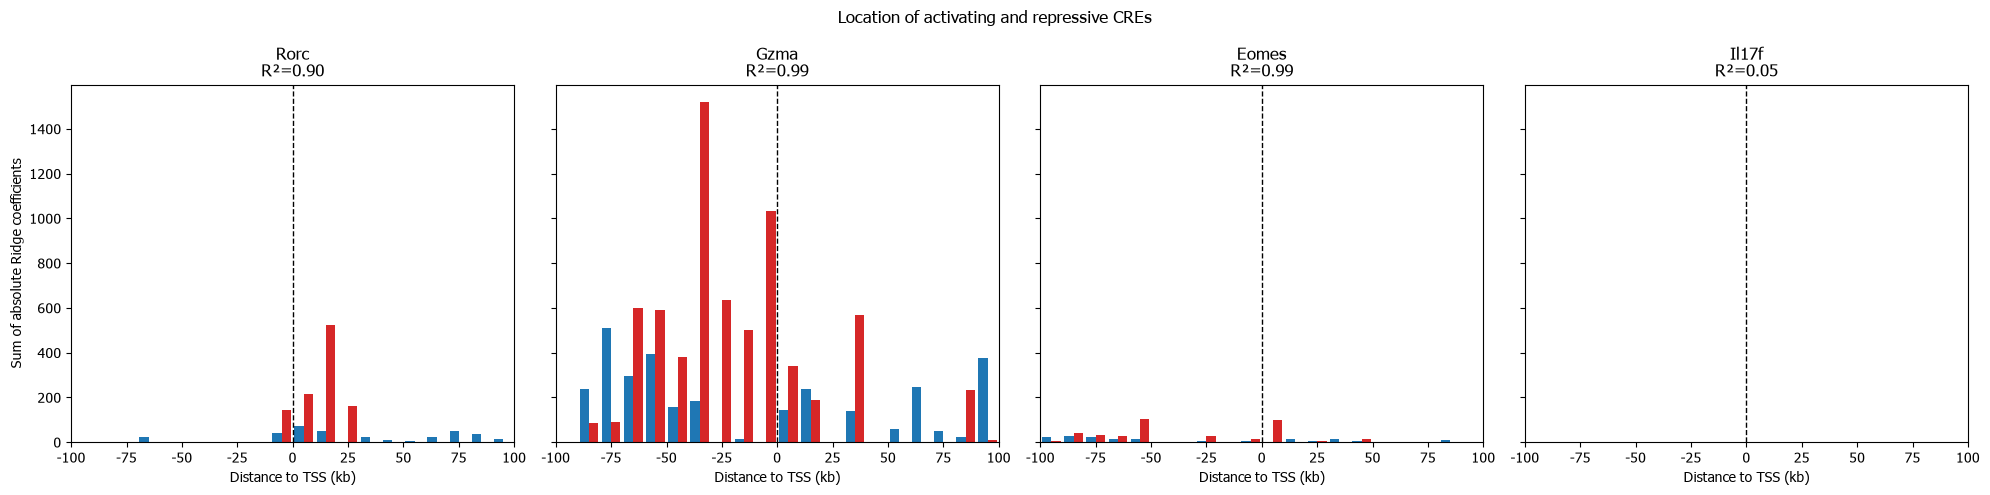

In [ ]:
genes = ["Rorc", "Gzma", "Eomes", "Il17f"]

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5),
    sharey=True
)

for gen_name, ax in zip(genes, axes):

    # Daten für dieses Gen holen
    coef_df, r2, cv, _ = coef_gen(gen_name)

    coef_df = coef_df.copy()
    coef_df["peakID"] = coef_df["peakID"].astype(str)
    coef_df = coef_df.drop_duplicates(subset="peakID")

    # TSS
    tss_df = (
        Gene_annotations.loc[
            Gene_annotations["gene_name"] == gen_name,
            ["gene_name", "TSS_pos"]
        ]
        .drop_duplicates("gene_name")
    )

    # Peakpositionen
    peak_position_df = (
        ATACseq_gd_reg[
            ["ImmGenATAC1219.peakID", "Summit"]
        ]
        .rename(columns={"ImmGenATAC1219.peakID": "peakID"})
        .copy()
    )

    peak_position_df["peakID"] = peak_position_df["peakID"].astype(str)

    # Mergen
    plot_df = (
        coef_df
        .merge(peak_position_df, on="peakID")
        .merge(tss_df, how="cross")
    )

    # Distanz
    plot_df["distance"] = (
        plot_df["Summit"] - plot_df["TSS_pos"]
    )

    plot_df = plot_df[
        (plot_df["distance"].abs() <= 100000)
        & (plot_df["coefficient"] != 0)
    ].copy()

    # aktivierend/repressiv
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    plot_df["abs_coef_raw"] = (
        plot_df["coefficient"].abs()
    )

    # Histogramme
    bins = np.arange(-100000, 100001, 10000)
    centers = (bins[:-1] + bins[1:]) / 2

    activating, _ = np.histogram(
        plot_df.loc[
            plot_df["effect"] == "activating",
            "distance"
        ],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive, _ = np.histogram(
        plot_df.loc[
            plot_df["effect"] == "repressive",
            "distance"
        ],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    width = 10000 * 0.42

    ax.bar(
        centers - width/2,
        repressive,
        width=width,
        color="#1f77b4"
    )

    ax.bar(
        centers + width/2,
        activating,
        width=width,
        color="#d62728"
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{gen_name}\nR²={r2:.2f}"
    )

    ax.set_xlim(-100000, 100000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{int(x/1000)}"
        )
    )

axes[0].set_ylabel(
    "Sum of absolute Ridge coefficients"
)

for ax in axes:
    ax.set_xlabel("Distance to TSS (kb)")

plt.suptitle(
    "Location of activating and repressive CREs"
)

plt.tight_layout()
plt.show()

### 2.4.8: Are there CREs that repress one but activate another
- Do i check the whole Dataset, only those with Good CV or only our three genes?
- How can I plot this nicely? Check Yoshida maybe?
    - statistics might be viable -> 20% of genes are repressive controlled, strongest repressor is that gene, X% of GD-Tcells are repressive yada yada

### 2.4.9: CRE profile of a gene

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_cre_profiles(genes, strong_threshold=0.1):
    """
    Erstellt einen gestapelten Balken pro Gen.

    Kategorien:
    - repressive: coefficient < 0
    - weak activating: 0 < coefficient < strong_threshold
    - strong activating: coefficient >= strong_threshold
    """

    # Erlaubt sowohl einen einzelnen Gen-Namen als auch eine Liste von Genen
    if isinstance(genes, str):
        genes = [genes]

    # Einheitliche Schrift für den Plot
    plt.rcParams.update({
        "font.family": "Tahoma",
        "font.size": 10
    })

    categories = ["repressive", "weak activating", "strong activating"]

    # Zwei ähnliche Rottöne für schwach/stark aktivierende CREs
    colors = {
        "repressive": "#4C78A8",        # blau
        "weak activating": "#F2A0A0",   # hellrot
        "strong activating": "#C94C4C"  # dunkelrot
    }

    all_summaries = []
    model_info = []

    for gen_name in genes:

        # Ridge-Koeffizienten für das jeweilige Gen holen
        coef_df, r2, cv, _ = coef_gen(gen_name)

        coef_df = coef_df.copy()
        coef_df["peakID"] = coef_df["peakID"].astype(str)

        # Sicherheit: doppelte Peak-IDs nur einmal zählen
        coef_df = coef_df.drop_duplicates(subset="peakID")

        # Peaks ohne Effekt ausschließen
        coef_df = coef_df[coef_df["coefficient"] != 0].copy()

        # Kategorie anhand von Richtung und Stärke festlegen
        coef_df["cre_class"] = np.select(
            [
                coef_df["coefficient"] < 0,

                (coef_df["coefficient"] > 0)
                & (coef_df["coefficient"] < strong_threshold),

                coef_df["coefficient"] >= strong_threshold
            ],
            [
                "repressive",
                "weak activating",
                "strong activating"
            ],
            default="other"
        )

        # Anzahl der CREs je Kategorie zählen
        gene_summary = (
            coef_df["cre_class"]
            .value_counts()
            .reindex(categories, fill_value=0)
            .rename_axis("cre_class")
            .reset_index(name="count")
        )

        gene_summary["gene"] = gen_name
        all_summaries.append(gene_summary)

        model_info.append({
            "gene": gen_name,
            "R2": r2,
            "CV": cv
        })

    # Alle Gen-Zusammenfassungen in einem DataFrame kombinieren
    summary_df = pd.concat(all_summaries, ignore_index=True)
    model_info_df = pd.DataFrame(model_info)

    # Plot vorbereiten
    fig, ax = plt.subplots(figsize=(1.8 * len(genes) + 3, 6))

    x_positions = np.arange(len(genes))
    bottom = np.zeros(len(genes))

    # Jede CRE-Kategorie als eigener gestapelter Abschnitt
    for category in categories:

        counts = (
            summary_df[summary_df["cre_class"] == category]
            .set_index("gene")
            .reindex(genes)["count"]
            .to_numpy()
        )

        bars = ax.bar(
            x_positions,
            counts,
            bottom=bottom,
            color=colors[category],
            edgecolor="black",
            linewidth=0.5,
            label=category
        )

        # Anzahl direkt in die jeweiligen Balkensegmente schreiben
        for x, count, current_bottom in zip(x_positions, counts, bottom):
            if count > 0:
                ax.text(
                    x,
                    current_bottom + count / 2,
                    str(int(count)),
                    ha="center",
                    va="center"
                )

        bottom += counts

    ax.set_xticks(x_positions)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Number of CREs")
    ax.set_title("CRE profiles based on Ridge regression coefficients")
    ax.legend(title="CRE category", frameon=True)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(summary_df.pivot(
        index="gene",
        columns="cre_class",
        values="count"
    ).reindex(columns=categories, fill_value=0))

    display(model_info_df)

    return summary_df, model_info_df, fig, ax

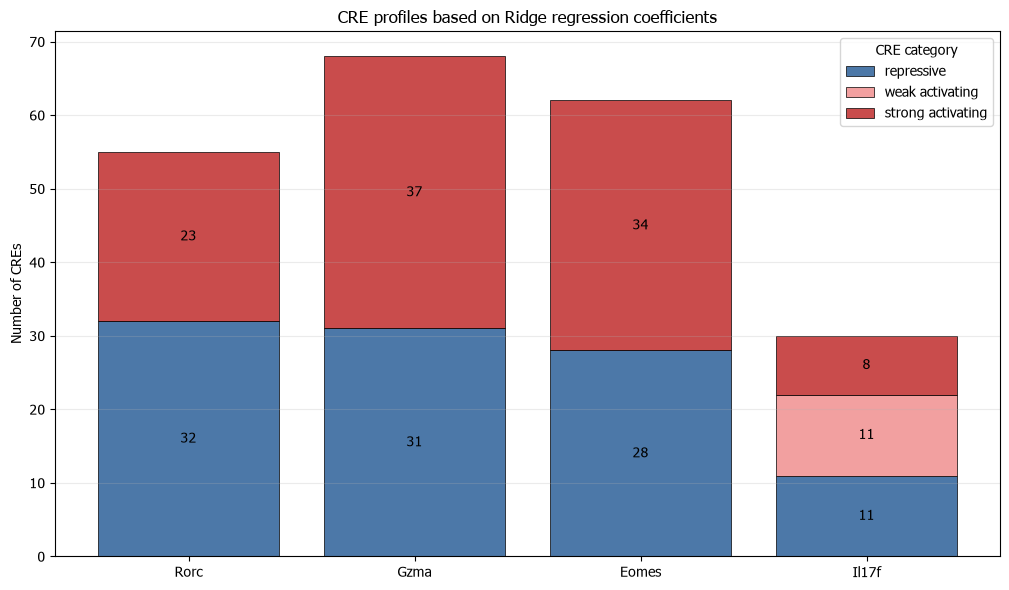

cre_class,repressive,weak activating,strong activating
gene,,,
Eomes,28,0,34
Gzma,31,0,37
Il17f,11,11,8
Rorc,32,0,23


,gene,R2,CV
0,Rorc,0.904932,0.658815
1,Gzma,0.985775,0.898852
2,Eomes,0.985806,0.927763
3,Il17f,0.054160,-4.164616


In [ ]:
genes = ["Rorc", "Gzma", "Eomes", "Il17f"]

cre_summary, model_info, fig, ax = plot_cre_profiles(
    genes,
    strong_threshold=0.1
)

### 2.4.10: Genome Track

In [ ]:
display(coef_df.head())
print(coef_df.columns)


,peakID,coefficient,sign,abs_coefficient
0,ImmGenATAC1219.peak_2700,-0.003976,-,0.0
1,ImmGenATAC1219.peak_2701,-0.004213,-,0.0
2,ImmGenATAC1219.peak_2702,-0.002853,-,0.0
3,ImmGenATAC1219.peak_2703,0.003842,+,0.0
4,ImmGenATAC1219.peak_2704,-0.000444,-,0.0


Index(['peakID', 'coefficient', 'sign', 'abs_coefficient'], dtype='str')


In [ ]:
#dictionary with all genes listed and their respective peaks within 100kb
gene_peak_dictionary

gene_peak_dictionary_100 = dict(list(gene_peak_dictionary.items())[:100])


#dictionary with all genes listed and the abs_coef of all their peaks

gene_coef_dictionary = {}

for gen_name in gene_peak_dictionary.keys():
    try:
        coef_df, r2, cv, peak_ids = coef_gen(gen_name)
        
        peak_coef_dict = dict(zip(coef_df["peakID"],coef_df["coefficient"]))

        gene_coef_dictionary[gen_name] = {
                "cv": cv,
                "r2": r2,
                "coefs": peak_coef_dict}
    
    except Exception as e:
        gene_coef_dictionary[gen_name] = {
                "cv": None,
                "r2": None,
                "coefs": {},
                "error": str(e)
            }

gene_coef_dictionary.to_csv("data/gene_coef_dictionary.csv", index=False)
gene_coef_dictionary


C:\Users\peter\AppData\Local\Temp\ipykernel_7880\2616991476.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]


AttributeError: 'dict' object has no attribute 'to_csv'

In [ ]:
gene_coef_df = pd.DataFrame.from_dict(
    gene_coef_dictionary,
    orient="index"
).reset_index()

gene_coef_df = gene_coef_df.rename(
    columns={"index": "gene"}
)

display(gene_coef_df)

gene_coef_df.to_csv("data/gene_coef_dictionary.csv", index=False)



,gene,cv,r2,coefs,error
0,Xkr4,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
1,Rp1,-1.122908,0.887571,"{'ImmGenATAC1219.peak_48': 1.7791684818132834,...",NaN
2,Sox17,-427.130314,0.572920,"{'ImmGenATAC1219.peak_82': 4.527048421275342, ...",NaN
3,Mrpl15,0.167903,0.387567,"{'ImmGenATAC1219.peak_119': 12.27785531993507,...",NaN
4,Lypla1,-0.060274,0.073396,"{'ImmGenATAC1219.peak_125': 2.048810672896512,...",NaN
...,...,...,...,...,...
23422,Ddx3y,0.335150,0.536000,{'ImmGenATAC1219.peak_512533': 28.995622794885...,NaN
23423,Rbmy,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
23424,Gm21708,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
23425,Gm3376,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
